In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [58]:
df =pd.read_csv('/content/deliveries.csv')

In [59]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [60]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [62]:
df.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [63]:
df=df.drop('extras_type',axis=1)

In [64]:
df=df.drop(columns=['player_dismissed', 'dismissal_kind', 'fielder'])

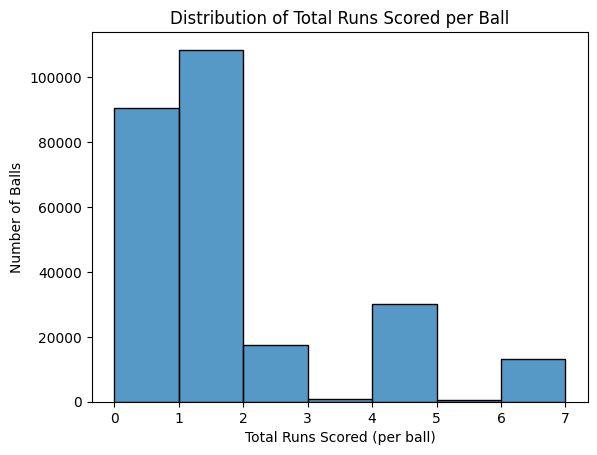

In [65]:
sns.histplot(df['total_runs'], bins=range(0, 8))
plt.xlabel('Total Runs Scored (per ball)')
plt.ylabel('Number of Balls')
plt.title('Distribution of Total Runs Scored per Ball')
plt.show()

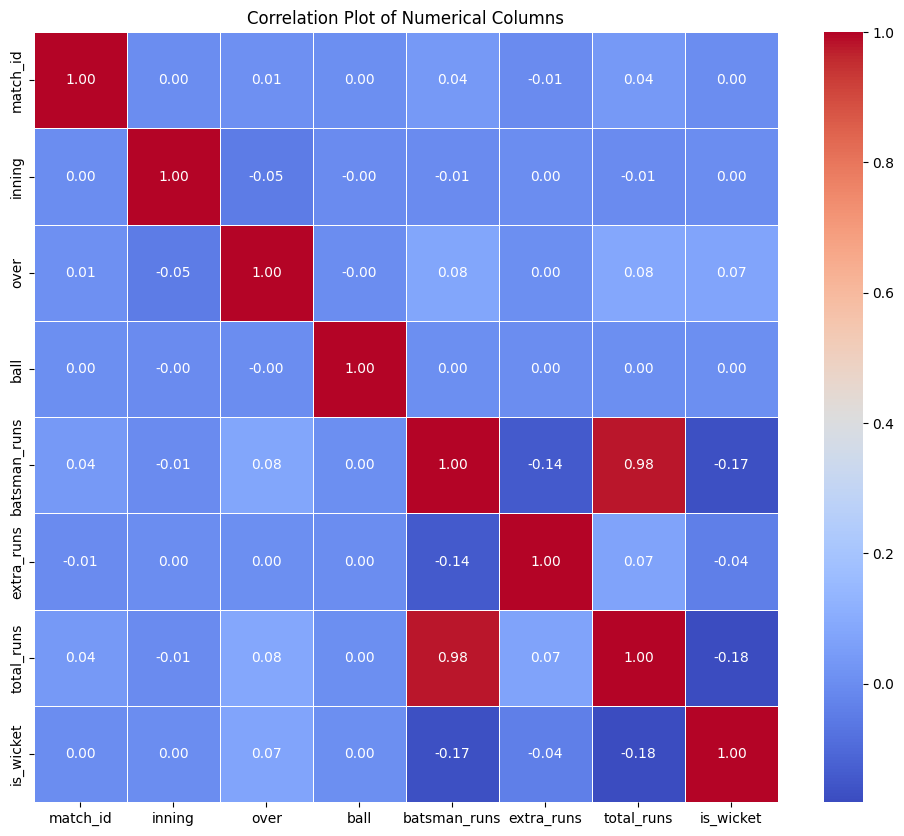

In [66]:
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Plot of Numerical Columns')
plt.show()

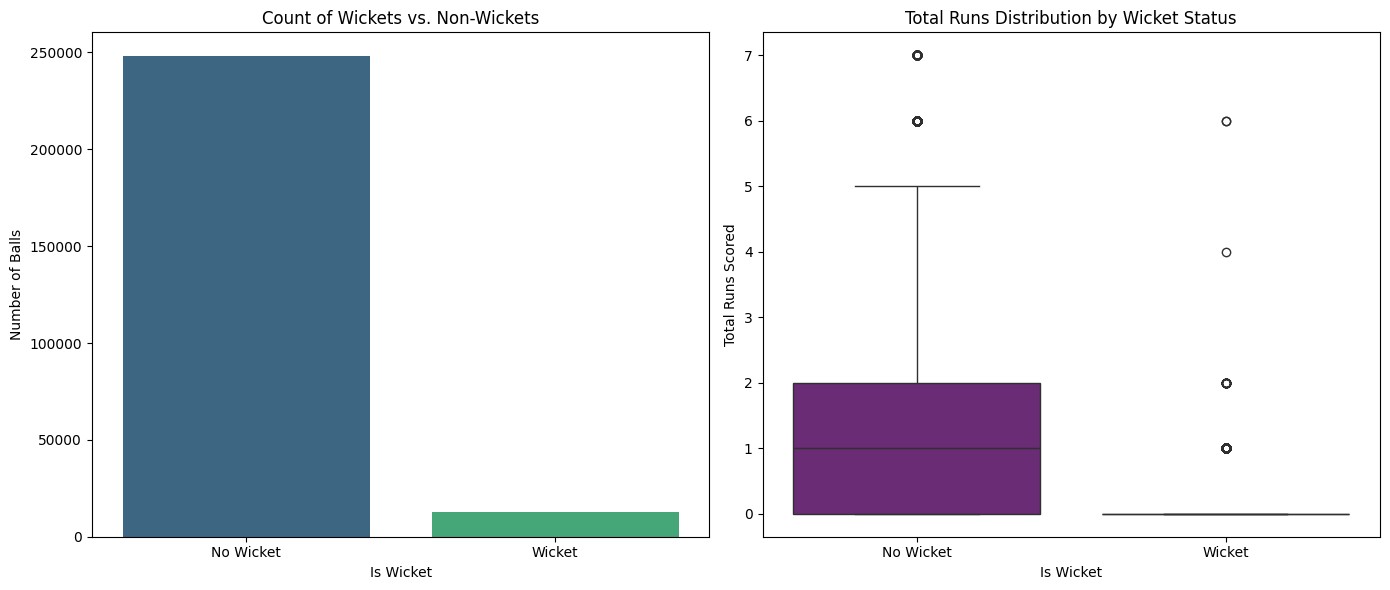

In [67]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='is_wicket', data=df, hue='is_wicket', palette='viridis', legend=False)
plt.title('Count of Wickets vs. Non-Wickets')
plt.xlabel('Is Wicket')
plt.ylabel('Number of Balls')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.subplot(1, 2, 2)
sns.boxplot(x='is_wicket', y='total_runs', data=df, hue='is_wicket', palette='magma', legend=False)
plt.title('Total Runs Distribution by Wicket Status')
plt.xlabel('Is Wicket')
plt.ylabel('Total Runs Scored')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.tight_layout()
plt.show()

In [68]:
final_df =df.drop(columns=['match_id','inning','ball','non_striker','batting_team','bowling_team','batter','bowler'])

In [69]:
final_df.head()

,over,batsman_runs,extra_runs,total_runs,is_wicket
0,0,0,1,1,0
1,0,0,0,0,0
2,0,0,1,1,0
3,0,0,0,0,0
4,0,0,0,0,0


In [70]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   over          260920 non-null  int64
 1   batsman_runs  260920 non-null  int64
 2   extra_runs    260920 non-null  int64
 3   total_runs    260920 non-null  int64
 4   is_wicket     260920 non-null  int64
dtypes: int64(5)
memory usage: 10.0 MB


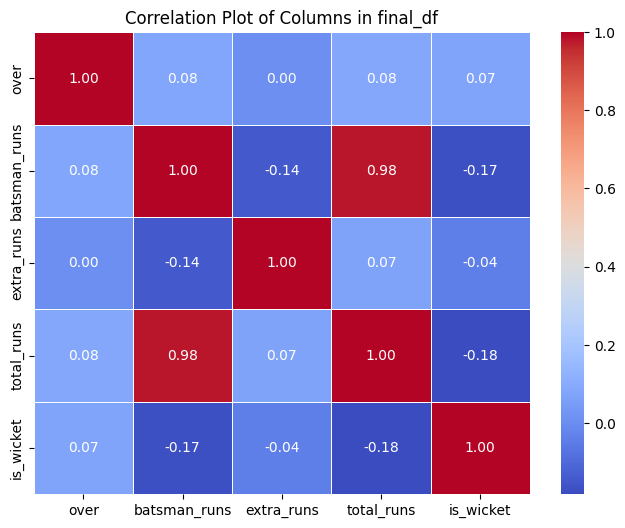

In [71]:
correlation_matrix_final = final_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_final, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Plot of Columns in final_df')
plt.show()

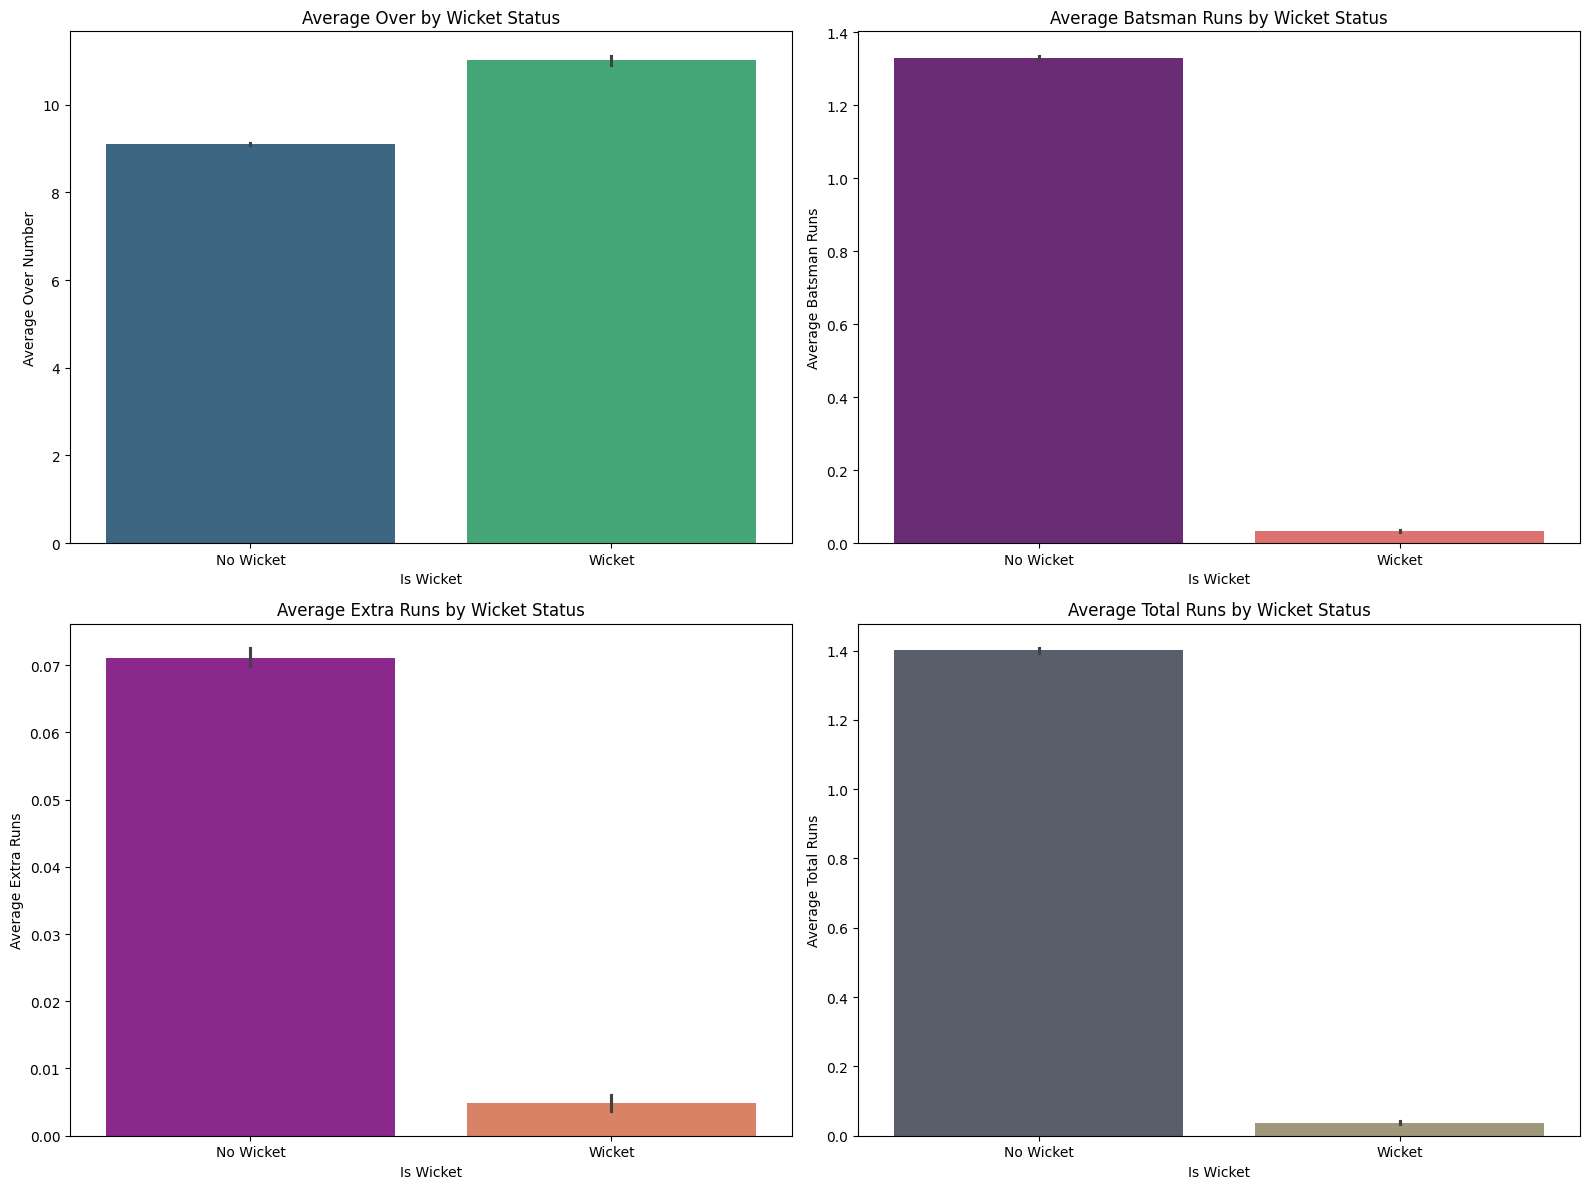

In [72]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.barplot(x='is_wicket', y='over', data=final_df, hue='is_wicket', palette='viridis', legend=False)
plt.title('Average Over by Wicket Status')
plt.xlabel('Is Wicket')
plt.ylabel('Average Over Number')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.subplot(2, 2, 2)
sns.barplot(x='is_wicket', y='batsman_runs', data=final_df, hue='is_wicket', palette='magma', legend=False)
plt.title('Average Batsman Runs by Wicket Status')
plt.xlabel('Is Wicket')
plt.ylabel('Average Batsman Runs')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.subplot(2, 2, 3)
sns.barplot(x='is_wicket', y='extra_runs', data=final_df, hue='is_wicket', palette='plasma', legend=False)
plt.title('Average Extra Runs by Wicket Status')
plt.xlabel('Is Wicket')
plt.ylabel('Average Extra Runs')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.subplot(2, 2, 4)
sns.barplot(x='is_wicket', y='total_runs', data=final_df, hue='is_wicket', palette='cividis', legend=False)
plt.title('Average Total Runs by Wicket Status')
plt.xlabel('Is Wicket')
plt.ylabel('Average Total Runs')
plt.xticks([0, 1], ['No Wicket', 'Wicket'])

plt.tight_layout()
plt.show()